## Pipeline with recommendations from Google

In [1]:
from dotenv import load_dotenv
import os
from scripts_D.test_pipeline3 import SpinePipeline
import cv2
from paddleocr import PaddleOCR
import glob
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt

d:\Virtual Environments\pipeline_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\Virtual Environments\pipeline_venv\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dawoo\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dawoo\.paddl

In [2]:
load_dotenv()
api_key = os.getenv("Google_Books_API")

In [3]:
pl = SpinePipeline(
    catalog_path=r"D:\Documents\python codes\Book Recommender\MVP\Dataset\books_cleaned.csv",
    chroma_path=r"D:\Documents\python codes\Book Recommender\MVP\chroma_db",
    collection_name="books",
    google_books_api_key=api_key
)

In [4]:
img = cv2.imread(r'D:\Documents\python codes\Book Recommender\MVP\test_images\eng.jpg')

In [5]:
output = pl.results(img)

print("Query strings:", output["query_strings"])

for m in output["matches"]:
    print(m["source"], "-", m["matched_title"], "-", len(m.get("recommendations", [])), "recs")

Query strings: ['READINGS(CLASSICS MAXIM GORKY MOTHER', 'THE PLAGUE ALBERT CAMUS', 'A TALE OF TWO CITIES Charles Dickens READINGS', 'A FAREWELL TO ARMS Ernest Hemingway', 'Orlando EG', 'READINGS(CLASSICS EMILY BRONTE WUTHERING HEIGHTS', 'FRANZ KAFKA THE TRIAL READINGS(CLASSICS', 'SIDDHARTHA HERMANN HESSE']
local_catalog - The Plague - 5 recs
local_catalog - A Farewell to Arms - 5 recs
local_catalog - Orlando - 5 recs
local_catalog - Wuthering Heights - 5 recs
local_catalog - The Trial - 5 recs
google_books - A Tale of Two Cities - 5 recs
google_books - Siddhartha - 5 recs


In [6]:
pl.display_results(output)

Detected spines: 8
Resolved matches: 7

[1] The Plague
    Source: local_catalog
    OCR text: THE PLAGUE ALBERT CAMUS
    Authors: Albert Camus
    ISBN13: 9780141185132
    Match score: 100.0
    Recommendations (5):
      - The Plague by Albert Camus  (distance: 0.355)
      - Montaillou by Emmanuel Le Roy Ladurie  (distance: 0.400)
      - The War by Marguerite Duras  (distance: 0.404)
      - A Journal of the Plague Year by Daniel Defoe  (distance: 0.414)
      - Jacques the Fatalist and His Master by Denis Diderot  (distance: 0.425)

[2] A Farewell to Arms
    Source: local_catalog
    OCR text: A FAREWELL TO ARMS Ernest Hemingway
    Authors: Ernest Hemingway
    ISBN13: 9780099910107
    Match score: 100.0
    Recommendations (5):
      - Hemingway by Jeffrey Meyers  (distance: 0.205)
      - CliffsNotes on Hemingway's The Sun Also Rises by Gary Carey  (distance: 0.316)
      - All Quiet on the Western Front by Erich Maria Remarque  (distance: 0.317)
      - The First Forty-nin

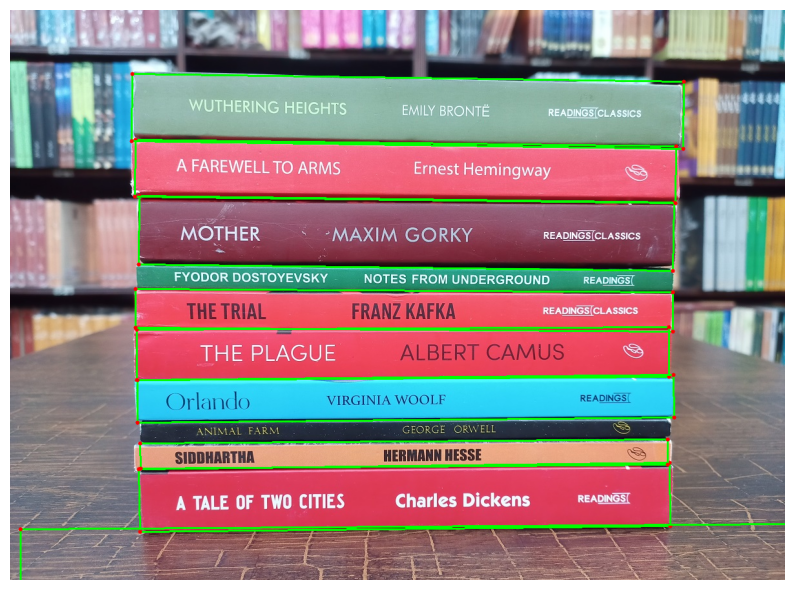

In [7]:
boxes = pl.detect_spines(img)

boxes = np.array(boxes, dtype=np.float32)  # Replace with your array

# Make a copy so the original image is unchanged
img = img.copy()

for box in boxes:
    # Convert to integer coordinates
    pts = box.astype(np.int32).reshape((-1, 1, 2))

    # Draw the polygon
    cv2.polylines(img, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

    # Optional: draw the corner points
    for x, y in box:
        cv2.circle(img, (int(x), int(y)), 3, (0, 0, 255), -1)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Cropping Peprocessing and OCR

In [8]:
model = YOLO("models/best_obb.pt")

test_images = glob.glob("test_images/img2.jpg")
print(f"Found {len(test_images)} test images")

results = model.predict(
    source=img,
    save=True,
    project=r"..\MVP\output-D",
    name=r"D:\Documents\python codes\Book Recommender\MVP\output-D\predict_obb_best",
    exist_ok=True,
    conf=0.5,
    iou=0.4,
)

Found 1 test images

0: 480x640 9 0s, 88.3ms
Speed: 5.6ms preprocess, 88.3ms inference, 3.9ms postprocess per image at shape (1, 3, 480, 640)
Results saved to D:\Documents\python codes\Book Recommender\MVP\output-D\predict_obb_best


In [9]:
# output_dir = r"..\MVP\output-D\crops_obb"
# os.makedirs(output_dir, exist_ok=True)


# def order_points(pts):
#     """
#     Order points as:
#     top-left, top-right, bottom-right, bottom-left
#     """
#     pts = np.array(pts, dtype=np.float32)

#     rect = np.zeros((4, 2), dtype=np.float32)

#     s = pts.sum(axis=1)
#     rect[0] = pts[np.argmin(s)]      # Top-left
#     rect[2] = pts[np.argmax(s)]      # Bottom-right

#     diff = np.diff(pts, axis=1)
#     rect[1] = pts[np.argmin(diff)]   # Top-right
#     rect[3] = pts[np.argmax(diff)]   # Bottom-left

#     return rect



# for img_path, result in zip(test_images, results):
#     img = cv2.imread(img_path)
#     img_name = os.path.splitext(os.path.basename(img_path))[0]

#     obb_corners = result.obb.xyxyxyxy.cpu().numpy()

#     for i, corners in enumerate(obb_corners):

#         # -------------------------------
#         # Reorder the corners correctly
#         # -------------------------------
#         corners = order_points(corners)


#         # -------------------------------
#         # Compute width
#         # -------------------------------
#         widthA = np.linalg.norm(corners[2] - corners[3])
#         widthB = np.linalg.norm(corners[1] - corners[0])
#         width = int(max(widthA, widthB))

#         # -------------------------------
#         # Compute height
#         # -------------------------------
#         heightA = np.linalg.norm(corners[1] - corners[2])
#         heightB = np.linalg.norm(corners[0] - corners[3])
#         height = int(max(heightA, heightB))

#         if width < 2 or height < 2:
#             continue

#         dst = np.array([
#             [0, 0],
#             [width - 1, 0],
#             [width - 1, height - 1],
#             [0, height - 1]
#         ], dtype=np.float32)


#         # -------------------------------
#         # Perspective transform
#         # -------------------------------
#         M = cv2.getPerspectiveTransform(corners, dst)

#         crop = cv2.warpPerspective(img, M, (width, height), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

#         # -------------------------------
#         # Rotate if vertical
#         # -------------------------------
#         # h, w = crop.shape[:2]
#         # if h > w:
#         #     crop = cv2.rotate(crop, cv2.ROTATE_90_CLOCKWISE)

        

#         crop_filename = os.path.join(output_dir, f"{img_name}_spine{i}.jpg")
#         cv2.imwrite(crop_filename, crop)

In [10]:
# paths = glob.glob(r"../MVP/output-D/crops_obb/*.jpg")
# os.makedirs(r"../MVP/output-D/pre_obb", exist_ok=True)

# clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# target_height = 256
# max_width = 1000
# max_scale = 3

# for path in paths:
#     img = cv2.imread(path)

#     # Convert to grayscale
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#     # CLAHE
#     gray = clahe.apply(gray)

#     # Resizing
#     h, w = gray.shape[:2]

#     scale = target_height / h
#     if scale > max_scale:
#         scale = max_scale

#     new_w = int(w * scale)
#     new_h = int(h * scale)

#     if new_w > max_width:
#         scale = max_width / w
#         new_w = max_width
#         new_h = int(h * scale)


#     interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC

#     resized = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=interpolation)

#     filename = os.path.basename(path)
#     cv2.imwrite(os.path.join(r"../MVP/output-D/pre_obb", filename), resized)

In [11]:
# # Initialize PaddleOCR
# paddle_ocr = PaddleOCR(
#     enable_mkldnn=False,
#     use_doc_orientation_classify=True,
#     use_doc_unwarping=False,
#     use_textline_orientation=True
# )

In [12]:
# CONFIDENCE_THRESHOLD = 0.8

# paths = glob.glob("output-D/pre_obb/*.jpg")

# filtered_results = []

# for path in paths:
#     img = cv2.imread(path)
#     ocr_results = paddle_ocr.predict(img, text_det_unclip_ratio=2.0)

#     img_name = os.path.splitext(os.path.basename(path))[0]

#     print(f'Image: {img_name}')

#     for res in ocr_results:
#         texts = res['rec_texts']
#         scores = res['rec_scores']

#         for text, score in zip(texts, scores):
#             if score >= CONFIDENCE_THRESHOLD:
#                 filtered_results.append({'image': img_name, 'text': text, 'confidence': score})
#                 print(f'Text: {text:30} Confidence: {score:.4f}')

Token_set_ratio - Extract One

[{'ocr_text': 'Friedrich Nietzsche Beyond Good and Evi',
  'matched_title': 'Twilight of Idols and Anti-Christ',
  'matched_authors': 'Friedrich Nietzsche',
  'isbn13': '9780140445145',
  'score': 74.19354838709677}]

Partial Ratio - Extract One
[]

WRatio
[]